# Chile: flexible-head fits for the choice-head ablation

Regenerate the five flexible-head coordinate fits and their held-out prediction metrics. This is the training counterpart of the positive symmetric fits in notebooks 02 and 04.

**Inputs:** the included `data/processed/Chile_pairs.parquet`, `Chile_split_assignments.parquet` and `participant_age_decisions.csv`. Saved-fit mode also reads weights, coordinates, history and properties from `outputs/models/flexible/Chile_dim2_seed*`. All inputs are included, so this notebook starts in a fresh kernel without running another notebook first.

**Outputs:** fitted coordinates and metrics in `outputs/models/flexible/`, `outputs/ablation/flexible/initialization_metrics.csv`, and training-curve PDFs in `outputs/figures/flexible/`. Notebook 14b calculates geometric agreement from these coordinates. Notebook 18 assembles the ablation table.

`REFIT = False` reloads the supplied weights and reevaluates the held-out choices. `REFIT = True` trains all five fits from the included comparisons, using the same participant/proposal indexing, split, initialization seeds, optimizer and batching procedure as the positive symmetric fits. Five full fits can take hours. To retain the supplied fits, set `OUTPUT_ROOT` to a separate directory before enabling refitting.

The two specifications learn their coordinates separately. This comparison changes the complete choice head, including its parameter count.

In [1]:
from pathlib import Path
import json
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import tensorflow as tf

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."
sys.path.insert(0, str(ROOT / "src"))
from choice_models import build_choice_model
assert tf.__version__.startswith("2.15."), "Use TensorFlow 2.15 as specified in requirements.txt."

PROCESSED = ROOT / "data/processed"
SAVED_MODELS = ROOT / "outputs/models/flexible"
OUTPUT_ROOT = ROOT / "outputs"
MODEL_OUTPUT = OUTPUT_ROOT / "models/flexible"
SUMMARY_OUTPUT = OUTPUT_ROOT / "ablation/flexible"
FIGURES = OUTPUT_ROOT / "figures/flexible"
REFIT = False
SEEDS = [101, 201, 301, 401, 501]
DIMENSION = 2
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.01
STEPS_PER_EXECUTION = 64
DEVICE = "/CPU:0"
assert len(SEEDS) == len(set(SEEDS)) and all(isinstance(s, int) and s >= 0 for s in SEEDS)
for folder in [MODEL_OUTPUT, SUMMARY_OUTPUT, FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)

## Sample and held-out partition

The index order and record order match the main Chilean training notebooks. Split labels are joined by both record and participant identifiers. Eight participants have one retained comparison, assigned to training. No demographic variable enters the network.

In [2]:
pairs = pd.read_parquet(PROCESSED / "Chile_pairs.parquet")
assignments = pd.read_parquet(PROCESSED / "Chile_split_assignments.parquet")
age = pd.read_csv(PROCESSED / "participant_age_decisions.csv", dtype={"uuid": "string"})
age = age.loc[age["country"].eq("Chile")].copy()
include = age["include"].astype(str).str.lower().map({"true": True, "false": False, "1": True, "0": False})
assert include.notna().all()
excluded_ids = set(age.loc[~include.astype(bool), "uuid"])
assert not set(pairs["uuid"]) & excluded_ids
assert pairs["id"].is_unique and assignments["id"].is_unique
assert len(pairs) == len(assignments)
ordered = pairs.sort_values(["uuid", "id", "datetime"], kind="mergesort").reset_index(drop=True)
ordered = ordered.merge(assignments, on=["id", "uuid"], how="left", validate="one_to_one", sort=False)
assert ordered["split"].isin(["train", "test"]).all()
assert (ordered["selected"].eq(ordered["option_a"]) | ordered["selected"].eq(ordered["option_b"])).all()
users = np.array(sorted(ordered["uuid"].unique()))
options = np.array(sorted(set(ordered["option_a"]) | set(ordered["option_b"])))
user_index = {u: i for i, u in enumerate(users)}
option_index = {p: i for i, p in enumerate(options)}
X = np.column_stack([ordered["option_a"].map(option_index), ordered["uuid"].map(user_index),
                     ordered["option_b"].map(option_index)]).astype(np.int32)
y = ordered["selected"].eq(ordered["option_a"]).to_numpy(dtype=np.int32)
in_train = ordered["split"].eq("train").to_numpy()
X_train, y_train = X[in_train], y[in_train]
X_test, y_test = X[~in_train], y[~in_train]
assert set(X_train[:, 1]) == set(range(len(users)))
assert set(X_test[:, 1]).issubset(set(X_train[:, 1]))
assert (len(users), len(options), len(y_train), len(y_test)) == (47574, 90, 2650103, 320244)
singleton_count = int(ordered.groupby("uuid").size().eq(1).sum())
sample = pd.DataFrame([{"participants": len(users), "proposals": len(options), "records": len(y),
                       "training_records": len(y_train), "test_records": len(y_test)}])
display(sample)
# Arrays, not demographic fields, are supplied to the network.
del X, y, pairs, assignments

,participants,proposals,records,training_records,test_records
0,47574,90,2970347,2650103,320244


## Fit or reload, then evaluate

The implementation name `original` selects the flexible four-branch head in `src/choice_models.py`. Its two-dimensional head contains 20 parameters in addition to 95,328 embedding parameters.

For each seed, the training dataset is shuffled, batched including the final incomplete batch, and repeated. Training retains the final of 20 epochs, without choosing a checkpoint by held-out performance. Loading verifies coordinate identifiers and the saved model properties before evaluating every held-out record. It does not continue optimizer training.

Loading flexible head, seed 101


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.433232,0.250332
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.417303,0.291082
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.431377,0.664093
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.363072,0.458100
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.407244,0.343025
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.300740,0.485654
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.611702,0.265895
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.474554,0.778633
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.360886,0.367367


,id,z1,z2
0,1,0.749003,0.451457
1,2,0.777782,1.000000
2,3,0.346607,0.432447
3,4,0.154296,0.554554
4,5,0.718914,0.195813
...,...,...,...
85,86,0.240740,0.612878
86,87,0.345685,0.394561
87,88,0.268359,0.699866
88,89,0.165260,0.388446


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.610543,0.664155,0.609520,0.666133
1,2,0.587349,0.687229,0.594212,0.681568
2,3,0.568174,0.704061,0.584609,0.690530
3,4,0.558355,0.712158,0.579475,0.693487
4,5,0.553640,0.716028,0.579042,0.694527
5,6,0.550995,0.718411,0.577829,0.695463
6,7,0.549327,0.719734,0.584467,0.696026
7,8,0.548137,0.720841,0.579182,0.696172
8,9,0.547325,0.721473,0.585256,0.695623
9,10,0.546620,0.722176,0.579857,0.696238


,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,101,47574,90,2970347,2650103,320244,0.581988,0.694517,0.694517,8,399.274233


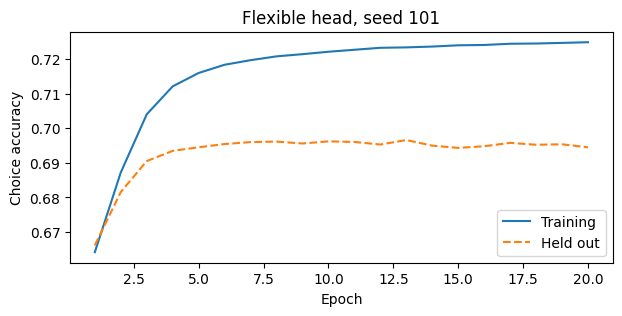

Loading flexible head, seed 201


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.541366,0.274343
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.219814,0.474239
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.733477,0.658859
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.435135,0.515226
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.527550,0.501089
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.648212,0.540372
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.232037,0.398084
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.797508,0.736066
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.288699,0.536517


,id,z1,z2
0,1,3.849332e-01,0.415214
1,2,5.213881e-09,0.521820
2,3,8.900035e-01,0.996335
3,4,5.664652e-01,0.382259
4,5,2.087445e-01,0.692581
...,...,...,...
85,86,6.014691e-01,0.318421
86,87,2.213287e-01,0.138008
87,88,7.174679e-01,0.372452
88,89,5.405883e-01,0.746274


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.605456,0.668853,0.600556,0.675657
1,2,0.578873,0.694371,0.592316,0.683341
2,3,0.568923,0.702233,0.588012,0.686383
3,4,0.564347,0.705644,0.587713,0.686570
4,5,0.562081,0.707076,0.587923,0.686211
5,6,0.560721,0.707637,0.589010,0.686324
6,7,0.559776,0.708244,0.588316,0.686586
7,8,0.559105,0.708142,0.588766,0.685758
8,9,0.558633,0.708404,0.589656,0.684990
9,10,0.558293,0.708680,0.589402,0.684790


,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,201,47574,90,2970347,2650103,320244,0.596482,0.680712,0.680712,8,523.808563


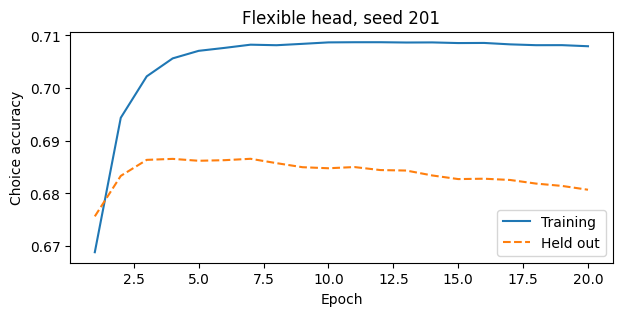

Loading flexible head, seed 301


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.330193,0.624196
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.428255,0.868886
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.638167,0.790030
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.471255,0.700765
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.462877,0.778963
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.540283,0.518391
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.345255,0.621058
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.697385,0.256762
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.483518,0.804152


,id,z1,z2
0,1,0.469330,0.535983
1,2,0.142988,1.000000
2,3,0.496458,1.000000
3,4,0.635339,0.331562
4,5,1.000000,0.571842
...,...,...,...
85,86,0.642510,0.256802
86,87,0.485671,0.180143
87,88,0.670708,0.543725
88,89,0.445493,0.854445


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.607361,0.665335,0.603230,0.671988
1,2,0.580268,0.692846,0.592278,0.682739
2,3,0.566271,0.705242,0.585813,0.691173
3,4,0.559009,0.711565,0.583594,0.691379
4,5,0.555984,0.713924,0.587532,0.692356
5,6,0.554125,0.715849,0.585444,0.692275
6,7,0.553247,0.716580,0.585021,0.692425
7,8,0.552925,0.716686,0.588148,0.691332
8,9,0.552797,0.717026,0.585225,0.691279
9,10,0.552710,0.717255,0.587104,0.690586


,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,301,47574,90,2970347,2650103,320244,0.595801,0.686274,0.686274,8,447.449291


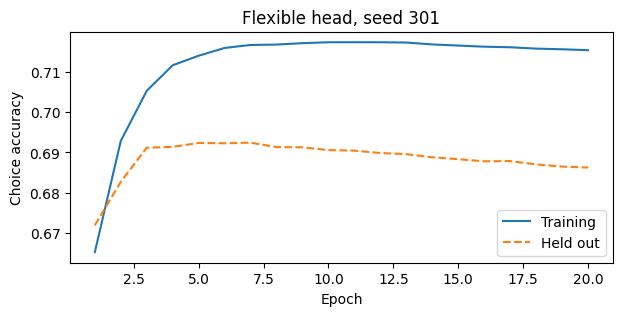

Loading flexible head, seed 401


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.384686,0.730439
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.510404,0.740787
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.681002,0.683177
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.625013,0.740120
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.528181,0.747503
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.575266,0.432351
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.378889,0.619780
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.725631,0.679236
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.527239,0.793509


,id,z1,z2
0,1,0.732298,1.000000e+00
1,2,0.570957,6.825558e-01
2,3,0.891194,1.458207e-07
3,4,0.412827,2.959770e-01
4,5,0.747059,7.041606e-01
...,...,...,...
85,86,0.344140,9.977741e-01
86,87,0.899665,9.999998e-01
87,88,0.371638,5.579258e-01
88,89,0.602771,1.149553e-01


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.613762,0.659014,0.609062,0.667301
1,2,0.586145,0.686990,0.593148,0.680625
2,3,0.570542,0.699911,0.588106,0.685643
3,4,0.564345,0.705160,0.588734,0.686592
4,5,0.561213,0.707382,0.587047,0.687014
5,6,0.559273,0.708758,0.588033,0.687448
6,7,0.557890,0.709992,0.589667,0.687913
7,8,0.556931,0.711043,0.587665,0.688216
8,9,0.556347,0.711466,0.589421,0.688609
9,10,0.555992,0.711658,0.590390,0.687726


,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,401,47574,90,2970347,2650103,320244,0.592323,0.685871,0.685871,8,492.066729


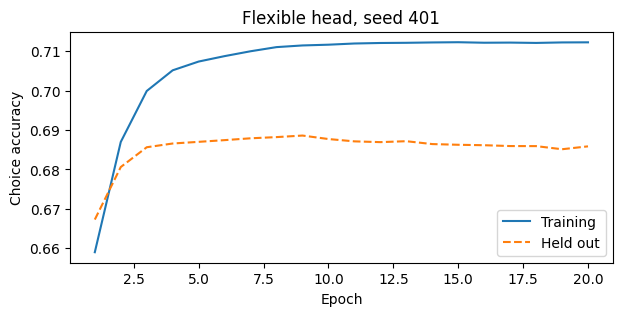

Loading flexible head, seed 501


,uuid,z1,z2
0,000057c7-295c-4a61-8f62-76aff62bf079,0.559841,0.314137
1,000059b8-10b9-4f74-9c01-80bd2c48f509,0.615561,0.330403
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.238254,0.505020
3,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.417775,0.419936
4,0006b923-77a6-40c1-95e0-f98b817bcab2,0.616364,0.275650
...,...,...,...
47569,fff8a6be-746b-4d24-9148-73c8c6accb69,0.255704,0.372932
47570,fffa9813-765b-46c6-87f6-47fa854e784f,0.746607,0.199644
47571,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.098640,0.521481
47572,fffe76d8-ea19-4360-8050-1aadfb982c54,0.576193,0.361516


,id,z1,z2
0,1,0.188812,0.253334
1,2,0.978005,0.873327
2,3,0.385268,0.344090
3,4,0.682513,0.553112
4,5,0.814473,0.147347
...,...,...,...
85,86,0.546120,0.534609
86,87,0.513260,0.318059
87,88,0.050581,0.528941
88,89,0.795219,0.411559


,epoch,loss,accuracy,val_loss,val_accuracy
0,1,0.612763,0.660188,0.613049,0.663997
1,2,0.596382,0.679070,0.604896,0.671800
2,3,0.580594,0.693441,0.594672,0.680940
3,4,0.570059,0.702842,0.590502,0.685630
4,5,0.563868,0.708240,0.587831,0.687260
5,6,0.560487,0.711009,0.587072,0.688684
6,7,0.558428,0.712994,0.586446,0.688694
7,8,0.557037,0.714045,0.588292,0.688862
8,9,0.556012,0.715004,0.586930,0.688606
9,10,0.555187,0.715591,0.587304,0.689087


,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,501,47574,90,2970347,2650103,320244,0.590149,0.687913,0.687913,8,463.08561


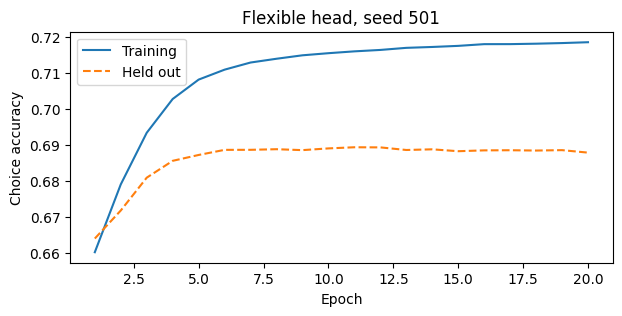

In [3]:
all_metrics = []
for seed in SEEDS:
    source = SAVED_MODELS / f"Chile_dim2_seed{seed}"
    run = MODEL_OUTPUT / f"Chile_dim2_seed{seed}"
    run.mkdir(parents=True, exist_ok=True)
    print(f"{'Training' if REFIT else 'Loading'} flexible head, seed {seed}")
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(len(y_train)).batch(BATCH_SIZE, drop_remainder=False).repeat()
    test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE, drop_remainder=False).repeat()
    with tf.device(DEVICE):
        model = build_choice_model(len(options), len(users), DIMENSION, seed, variant="original")
        model.compile(optimizer=tf.keras.optimizers.Adamax(learning_rate=LEARNING_RATE),
                      loss=tf.keras.losses.BinaryCrossentropy(), metrics=["accuracy"],
                      steps_per_execution=STEPS_PER_EXECUTION)
    assert model.count_params() - DIMENSION * (len(users) + len(options)) == 20
    specification = json.loads(model.choice_configuration_json)
    if not REFIT:
        required_files = ["properties.json", "model.weights.h5", "coordsU.csv", "coordsP.csv", "history.csv", "metrics.csv"]
        missing = [name for name in required_files if not (source / name).is_file()]
        if missing:
            raise FileNotFoundError(f"Missing saved files in {source}: {missing}. Restore the supplied fits or set REFIT=True.")
        properties = json.loads((source / "properties.json").read_text())
        for key, expected in {"seed": seed, "dimension": DIMENSION, "participants": len(users),
                              "proposals": len(options), "epochs": EPOCHS, "batch_size": BATCH_SIZE,
                              "learning_rate": LEARNING_RATE}.items():
            if properties[key] != expected:
                raise ValueError(f"Saved {key} disagrees for seed {seed}.")
        if properties.get("architecture") not in {"original", "original_sigmoid_coordinates_shared_exponential_branches"}:
            raise ValueError("The saved fit is not the flexible choice head.")
        if (source / "model_specification.json").is_file():
            assert json.loads((source / "model_specification.json").read_text()) == specification
        saved_u = pd.read_csv(source / "coordsU.csv", dtype={"uuid": str})
        saved_p = pd.read_csv(source / "coordsP.csv")
        assert saved_u["uuid"].tolist() == users.tolist()
        assert saved_p["id"].tolist() == options.tolist()
        model.load_weights(str(source / "model.weights.h5"))
        history_table = pd.read_csv(source / "history.csv")
        saved_metrics = pd.read_csv(source / "metrics.csv").iloc[0]
        for key, expected in {"participants": len(users), "proposals": len(options),
                              "training_records": len(y_train), "test_records": len(y_test)}.items():
            assert saved_metrics[key] == expected
        elapsed = float(saved_metrics["seconds"])
    else:
        started = time.perf_counter()
        with tf.device(DEVICE):
            history = model.fit(train_dataset, epochs=EPOCHS,
                steps_per_epoch=int(np.ceil(len(y_train) / BATCH_SIZE)),
                validation_data=test_dataset,
                validation_steps=int(np.ceil(len(y_test) / BATCH_SIZE)), verbose=2)
        elapsed = time.perf_counter() - started
        history_table = pd.DataFrame(history.history)
        history_table.insert(0, "epoch", np.arange(1, len(history_table) + 1))
        properties = {"country": "Chile", "dimension": DIMENSION, "seed": seed, "epochs": EPOCHS,
                      "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
                      "steps_per_execution": STEPS_PER_EXECUTION, "device": DEVICE,
                      "architecture": "original", "tensorflow_version": tf.__version__,
                      "participants": len(users), "proposals": len(options),
                      "checkpoint_selection": "fixed_final_epoch", "drop_remainder": False}
    assert len(history_table) == EPOCHS
    assert np.isfinite(history_table.select_dtypes("number")).all().all()
    with tf.device(DEVICE):
        evaluation = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0, return_dict=True)
    assert np.isfinite(list(evaluation.values())).all()
    row = {"country": "Chile", "dimension": DIMENSION, "seed": seed,
           "participants": len(users), "proposals": len(options), "records": len(ordered),
           "training_records": len(y_train), "test_records": len(y_test),
           "test_loss_all_records": evaluation["loss"], "test_accuracy_all_records": evaluation["accuracy"],
           "last_epoch_test_accuracy": float(history_table.iloc[-1]["val_accuracy"]),
           "singleton_participants_assigned_to_train": singleton_count, "seconds": elapsed}
    if not REFIT:
        if not np.isclose(row["test_accuracy_all_records"], saved_metrics["test_accuracy_all_records"], rtol=0, atol=1e-6):
            raise ValueError("Reloaded accuracy does not match the supplied fit. Check the sample, split and weights.")
    u = pd.DataFrame(model.layers[0].returnUsersEmbedding().numpy(), columns=["z1", "z2"])
    p = pd.DataFrame(model.layers[0].returnOptionsEmbedding().numpy(), columns=["z1", "z2"])
    u.insert(0, "uuid", users)
    p.insert(0, "id", options)
    for frame in [u, p]:
        assert np.isfinite(frame[["z1", "z2"]]).all().all()
    if not REFIT:
        np.testing.assert_allclose(u[["z1", "z2"]], saved_u[["z1", "z2"]], rtol=0, atol=2e-7)
        np.testing.assert_allclose(p[["z1", "z2"]], saved_p[["z1", "z2"]], rtol=0, atol=2e-7)
    # Show the live coordinates and fit history before any optional export.
    display(u)
    display(p)
    display(history_table)
    # Do not rewrite supplied coordinate decimals when merely reloading their weights.
    if REFIT or run.resolve() != source.resolve():
        u.to_csv(run / "coordsU.csv", index=False)
        p.to_csv(run / "coordsP.csv", index=False)
        history_table.to_csv(run / "history.csv", index=False)
        display(properties)
        display(specification)
        model.summary()
        (run / "properties.json").write_text(json.dumps(properties, indent=2) + "\n")
        (run / "model_specification.json").write_text(json.dumps(specification, indent=2) + "\n")
        model.save_weights(str(run / "model.weights.h5"))
    fit_metrics = pd.DataFrame([row])
    display(fit_metrics)
    fit_metrics.to_csv(run / "metrics.csv", index=False)
    all_metrics.append(row)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(history_table["epoch"], history_table["accuracy"], label="Training")
    ax.plot(history_table["epoch"], history_table["val_accuracy"], linestyle="--", label="Held out")
    ax.set(xlabel="Epoch", ylabel="Choice accuracy", title=f"Flexible head, seed {seed}")
    ax.legend()
    display(fig)
    fig.savefig(FIGURES / f"Chile_dim2_seed{seed}_training.pdf", bbox_inches="tight")
    plt.close(fig)

## Export metrics for the ablation

One row per initialization is passed to notebook 18. The positive symmetric metrics are generated by notebooks 02 and 04. Notebook 14b recomputes the flexible-head correlation matrices from the saved coordinates, rather than taking them from a benchmark table.

In [4]:
metrics = pd.DataFrame(all_metrics).sort_values("seed").reset_index(drop=True)
assert metrics["seed"].tolist() == sorted(SEEDS)
assert metrics["test_accuracy_all_records"].between(0, 1).all()
display(metrics)
ablation_metrics = metrics[["seed", "test_loss_all_records", "test_accuracy_all_records"]].copy()
display(ablation_metrics)
ablation_metrics.to_csv(SUMMARY_OUTPUT / "initialization_metrics.csv", index=False)
print("Wrote", SUMMARY_OUTPUT / "initialization_metrics.csv")

,country,dimension,seed,participants,proposals,records,training_records,test_records,test_loss_all_records,test_accuracy_all_records,last_epoch_test_accuracy,singleton_participants_assigned_to_train,seconds
0,Chile,2,101,47574,90,2970347,2650103,320244,0.581988,0.694517,0.694517,8,399.274233
1,Chile,2,201,47574,90,2970347,2650103,320244,0.596482,0.680712,0.680712,8,523.808563
2,Chile,2,301,47574,90,2970347,2650103,320244,0.595801,0.686274,0.686274,8,447.449291
3,Chile,2,401,47574,90,2970347,2650103,320244,0.592323,0.685871,0.685871,8,492.066729
4,Chile,2,501,47574,90,2970347,2650103,320244,0.590149,0.687913,0.687913,8,463.085610


,seed,test_loss_all_records,test_accuracy_all_records
0,101,0.581988,0.694517
1,201,0.596482,0.680712
2,301,0.595801,0.686274
3,401,0.592323,0.685871
4,501,0.590149,0.687913


Wrote /private/tmp/dynamap_release_check_2026-09-24/package/outputs/ablation/flexible/initialization_metrics.csv
